# Route flow graphs

`sameer_graph_lib` can turn a table of route rows into a directed
`pickup_cluster -> drop_cluster` graph where every edge carries a metric cube
over the grain dimensions (`week_period` x `hour` here).

This notebook covers the whole route stack:

1. build the graph from a DataFrame with one call
2. ask where a cluster's orders come from and where they go
3. plot that flow, several variables at a time, as tables on the nodes and edges
4. the supporting views: partners, profiles, matrix, whole graph
5. the stateless DataFrame plotter (multi-column, multi-axis, multi-group, distributions)

Install what it needs with `pip install -e ".[analysis]"`.

In [1]:
import sys, os
# Make the in-tree package importable without pip install -e .
_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src'))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import numpy as np
import pandas as pd

from sameer_graph_lib import RouteExplorer, plotter

pd.set_option('display.width', 110)
pd.set_option('display.max_columns', 20)

## 1. The input

One row per `pickup_cluster x drop_cluster x week_period x hour`, plus whatever
metric columns you export. The demo frame is synthetic: `A1` collects from
`C1..C6`, feeds `B1..B6`, and `C1`/`C2` are themselves fed by `D1..D6`, so the
graph has something to show two levels out in either direction.

Column names are yours - nothing in the library is hardcoded to these.

In [2]:
def make_demo_frame(seed=11):
    rng = np.random.default_rng(seed)
    edges = (
        [('A1', f'B{i}') for i in range(1, 7)]
        + [(f'C{i}', 'A1') for i in range(1, 7)]
        + [(f'D{i}', 'C1') for i in range(1, 5)]
        + [(f'D{i}', 'C2') for i in range(3, 7)]
        + [('A1', 'A2'), ('A2', 'A1'), ('B1', 'C1')]
    )
    rows = []
    for pickup, drop in edges:
        pull = rng.uniform(0.4, 2.0)
        for week_period in ('weekday', 'weekend'):
            for hour in range(24):
                if rng.random() < 0.25:          # not every bucket has data
                    continue
                peak = 1.8 if hour in (8, 9, 10, 18, 19, 20) else 1.0
                requests = float(rng.integers(20, 400) * pull * peak)
                rows.append({
                    'pickup_cluster': pickup,
                    'drop_cluster': drop,
                    'week_period': week_period,
                    'hour': hour,
                    'city': rng.choice(['north', 'south']),
                    'segment': rng.choice(['core', 'long', 'short']),
                    'variant': rng.choice(['test', 'control']),
                    'orders': requests * rng.uniform(0.2, 0.8),
                    'requests': requests,
                    'accepted_orders': requests * rng.uniform(0.1, 0.6),
                    'unfulfilled': float(rng.integers(0, 12)),
                    'supply_count': float(rng.integers(1, 60)),
                    'avg_distance': float(rng.uniform(1.5, 12)),
                    'avg_duration': float(rng.uniform(6, 45) / (peak * 0.8)),
                    'accept_rate': float(rng.uniform(0.3, 0.9)),
                })
    return pd.DataFrame(rows)

df = make_demo_frame()
print(f'{len(df):,} rows, {df.pickup_cluster.nunique()} pickup clusters')
df.head()

833 rows, 15 pickup clusters


  pickup_cluster drop_cluster week_period  hour   city segment  variant      orders    requests  \
0             A1           B1     weekday     0  south   short     test   42.676297  147.793807   
1             A1           B1     weekday     1  south    long  control   16.589792   45.428424   
2             A1           B1     weekday     2  south    core     test  126.696616  238.044944   
3             A1           B1     weekday     3  north   short     test   85.861566  234.410670   
4             A1           B1     weekday     5  north    long     test   77.254746  241.073505   

   accepted_orders  unfulfilled  supply_count  avg_distance  avg_duration  accept_rate  
0        83.371301          6.0           5.0      2.862626     53.731012     0.673130  
1         7.676679          4.0          47.0      8.538786     32.478638     0.790042  
2        81.366701         11.0          21.0      7.711751     18.970935     0.781322  
3        33.182823         11.0          53.0    

## 2. Build the graph

`RouteExplorer(df)` infers the schema (which columns are grains, which are
summed, which are averaged), builds one metric tensor per route and folds them
into the graph.

Columns named like averages (`avg_`, `_rate`, `pct`, ...) are weighted-averaged
by `requests`; the rest are summed. Grain, id and categorical columns are never
treated as metrics.

In [3]:
ex = RouteExplorer(df)
print(ex)
print()
print(ex.describe())

RouteExplorer(clusters=20, routes=23, metric='orders')

clusters        : 20
routes          : 23
rows folded in  : 23 group(s)
grains          : week_period (2), hour (24)
metrics         : 11 available, default 'orders'
bucket coverage : 75.4% of grain cells have data


In [4]:
print('summed  :', ex.schema.sum_metrics)
print('averaged:', ex.schema.mean_metrics)
print('default :', ex.schema.default_metric)
print()
print('everything you can pass as metric=:')
print(ex.metrics)

summed  : ['orders', 'requests', 'accepted_orders', 'unfulfilled', 'supply_count']
averaged: ['avg_distance', 'avg_duration', 'accept_rate']
default : orders

everything you can pass as metric=:
['row_count', 'orders', 'requests', 'accepted_orders', 'unfulfilled', 'supply_count', 'avg_distance', 'avg_duration', 'accept_rate', 'speed', 'count']


## 3. Where do the orders come from, and where do they go?

In [5]:
print('top sources of A1 (orders coming in)')
display(ex.sources('A1', top=5).round(1))

print('top drops of A1 (orders going out)')
display(ex.drops('A1', top=5).round(1))

top sources of A1 (orders coming in)
top drops of A1 (orders going out)


   rank cluster partner direction  orders  share  routes
0     1      A1      C4        in  8937.7    0.3       1
1     2      A1      C2        in  7567.3    0.3       1
2     3      A1      C3        in  4940.7    0.2       1
3     4      A1      A2        in  3891.2    0.1       1
4     5      A1      C1        in  3601.8    0.1       1


   rank cluster partner direction  orders  share  routes
0     1      A1      B4       out  8968.0    0.3       1
1     2      A1      B5       out  7492.8    0.2       1
2     3      A1      B6       out  6703.8    0.2       1
3     4      A1      B2       out  3900.8    0.1       1
4     5      A1      B3       out  3587.6    0.1       1


In [6]:
# the same expansion as a tree: top 5 sources, then the top 3 of each
print(ex.tree('A1', upstream=[5, 3], downstream=4))

A1  (orders)
  sources (orders coming in)
  |-- <- C4  [8,937.7]
  |-- <- C2  [7,567.3]
  |   |-- <- D3  [6,202.0]
  |   |-- <- D5  [4,650.1]
  |   +-- <- D4  [4,013.8]
  |-- <- C3  [4,940.7]
  |-- <- A2  [3,891.2]
  +-- <- C1  [3,601.8]
      |-- <- B1  [9,549.0]
      |-- <- D3  [7,453.1]
      +-- <- D4  [7,308.9]
  drops (orders going out)
  |-- -> B4  [8,968.0]
  |-- -> B5  [7,492.8]
  |-- -> B6  [6,703.8]
  +-- -> B2  [3,900.8]


In [7]:
# ...and as a tidy frame you can keep
ex.flow('A1', upstream=[4, 2], downstream=3, extra_metrics=['speed']).round(2).head(12)

     side  hop pickup_cluster drop_cluster   orders  routes  speed
0    drop    1             A1           B4  8967.96       1   0.25
1    drop    1             A1           B5  7492.83       1   0.26
2    drop    1             A1           B6  6703.78       1   0.26
3  source    1             C4           A1  8937.68       1   0.26
4  source    1             C2           A1  7567.31       1   0.36
5  source    1             C3           A1  4940.70       1   0.26
6  source    1             A2           A1  3891.22       1   0.29
7  source    2             D3           C2  6201.96       1   0.22
8  source    2             D5           C2  4650.14       1   0.21
9  source    2             A1           A2  1692.84       1   0.38

## 4. The flow plot

`plot` puts the focus clusters in the middle, the clusters that feed them on the
left and the clusters they feed on the right. `upstream` / `downstream` take an
int for one level or a list for one top-k per level, so `[5, 3, 2]` means *top 5,
then the top 3 of each of those, then the top 2 of each of those*.

`node_metrics` and `edge_metrics` take any number of variables and draw them as
an aligned table, so you are not limited to one number per node.

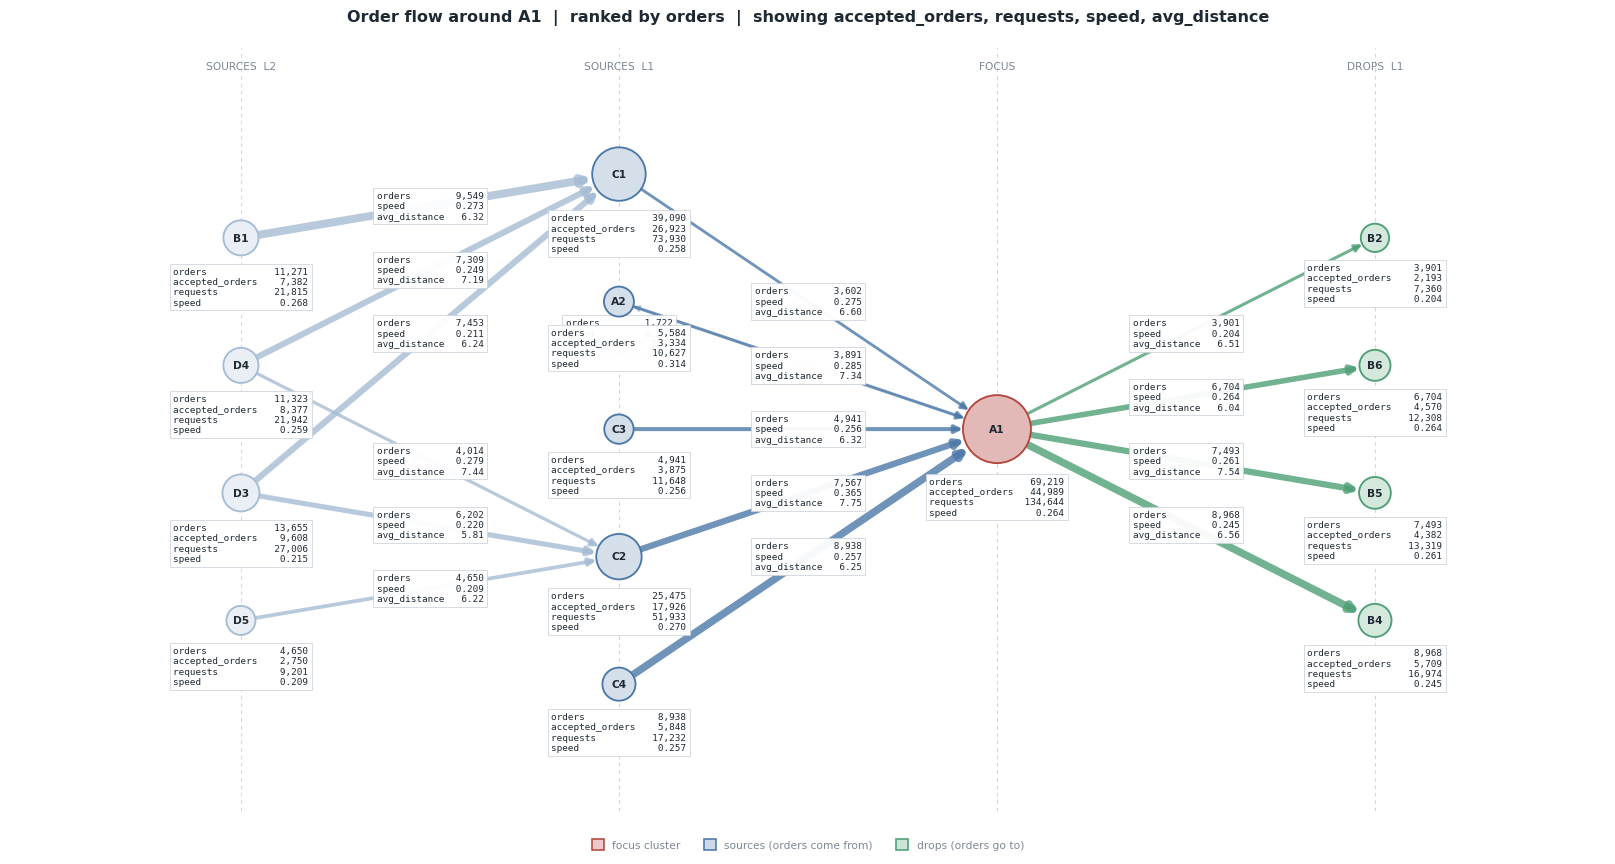

In [8]:
ex.plot(
    'A1',
    upstream=[5, 3, 2],
    downstream=[4, 2],
    node_metrics=['orders', 'accepted_orders', 'requests', 'speed'],
    edge_metrics=['orders', 'speed', 'avg_distance'],
)

### Narrowing it down

`where(...)` restricts the grain buckets and `using(...)` changes the default
metric. Both return a new view over the same graph, so nothing is rebuilt.

Here the ranking, the tables and the number formats are all different.

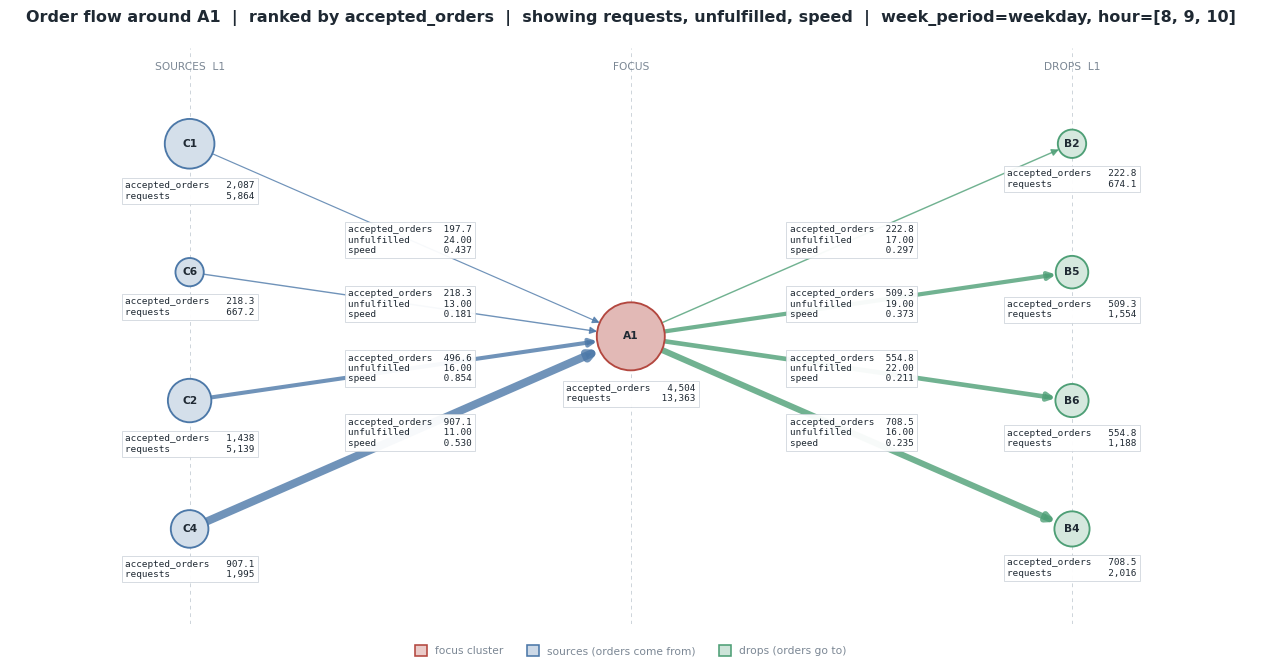

In [9]:
peak = ex.where(week_period='weekday', hour=[8, 9, 10])

peak.plot(
    'A1',
    upstream=4,
    downstream=4,
    metric='accepted_orders',                       # what the ranking uses
    node_metrics=['accepted_orders', 'requests'],   # what the node tables show
    edge_metrics=['accepted_orders', 'unfulfilled', 'speed'],
    value_format={'speed': '{:.3f}'},               # per-metric formats
)

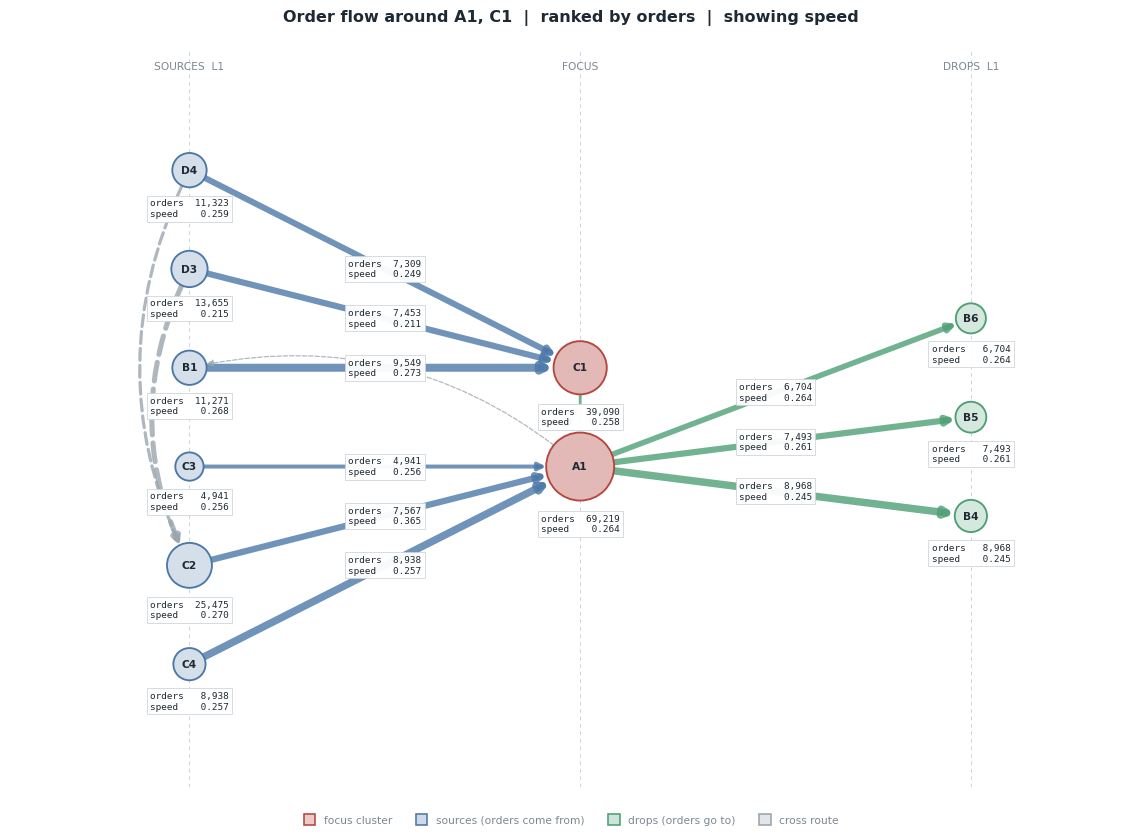

In [10]:
# two focus clusters at once, including the routes between the selected set
ex.plot(
    ['A1', 'C1'],
    upstream=3,
    downstream=3,
    include_cross_edges=True,
    node_metrics=['orders', 'speed'],
    edge_metrics=['orders', 'speed'],
)

## 5. Supporting views

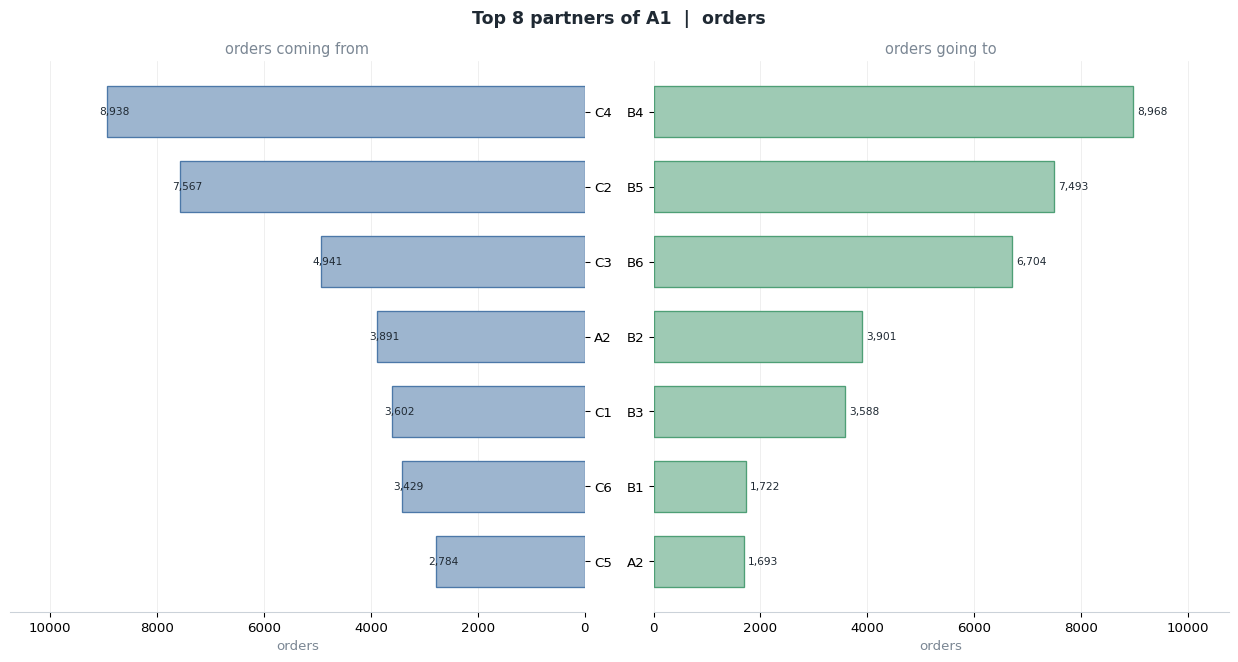

In [11]:
ex.plot_partners('A1', top=8)      # both panels share one scale

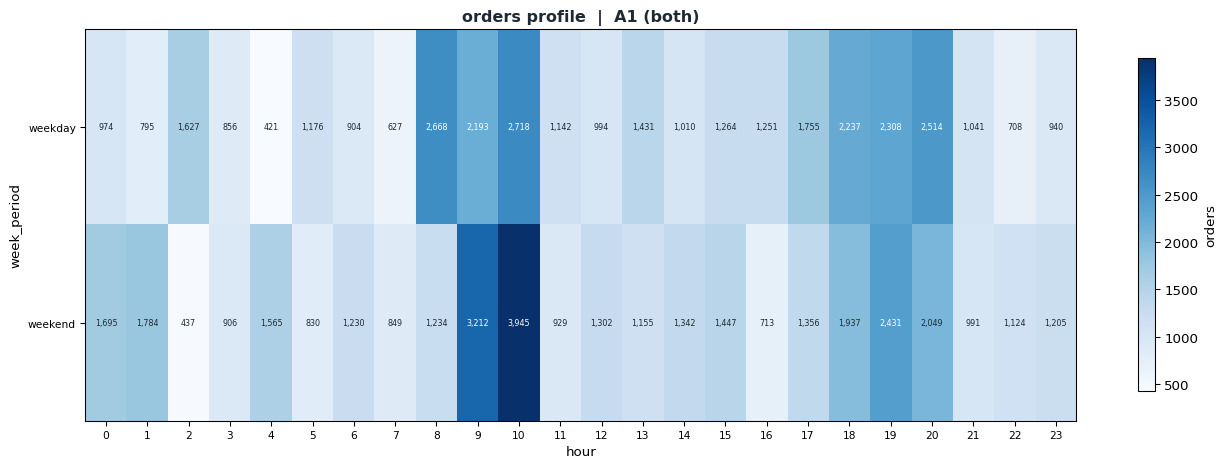

In [12]:
ex.plot_profile(cluster='A1', metric='orders')     # week_period x hour

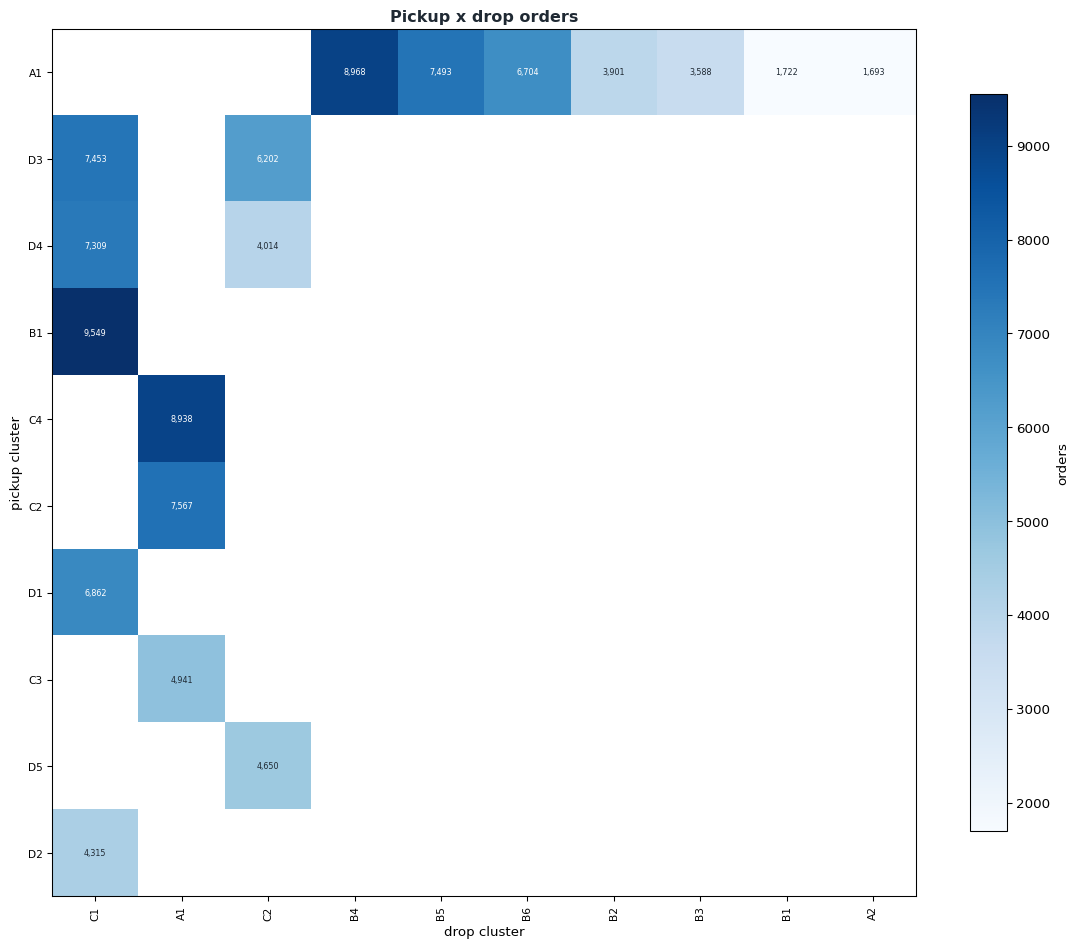

In [13]:
ex.plot_matrix(top=10)             # pickup x drop

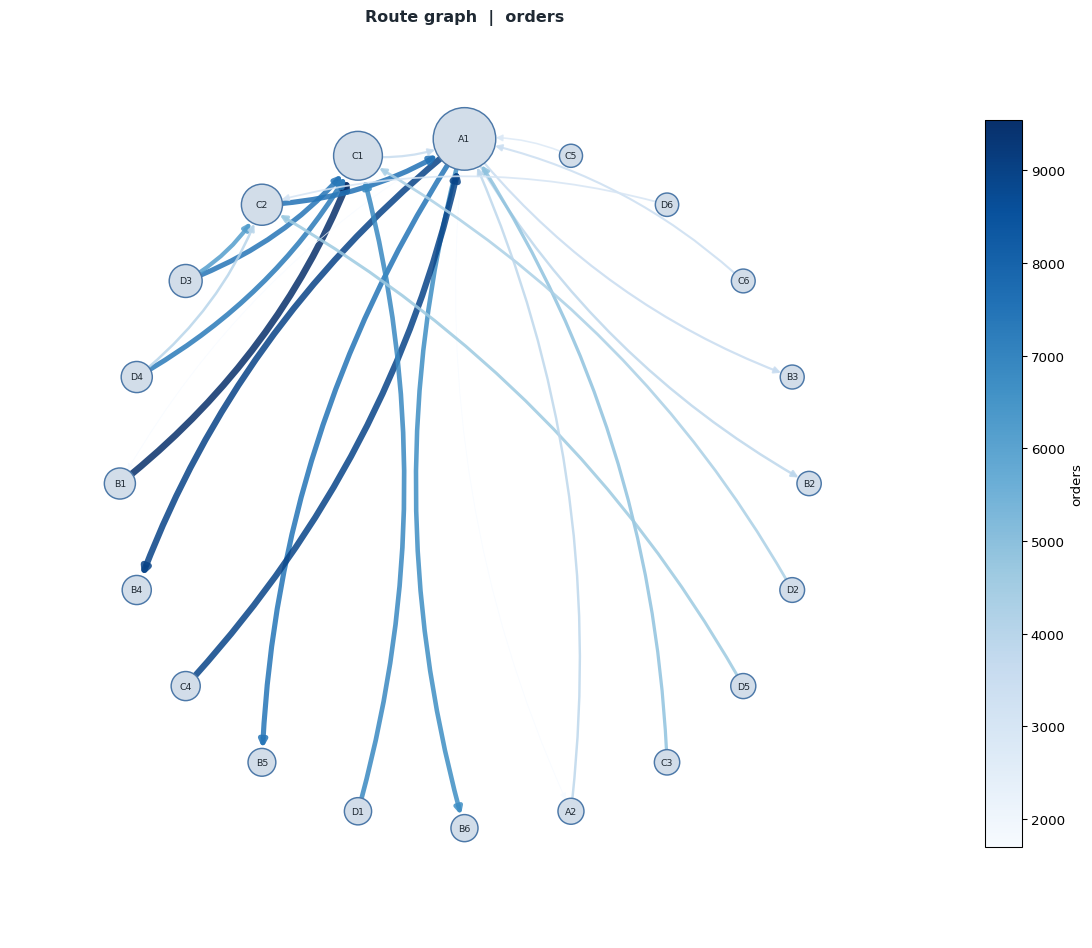

In [14]:
ex.plot_graph(top_routes=25)       # clusters ranked around the ring

### Tables rather than pictures

Everything above is available as a DataFrame.

In [15]:
print('routes ranked by the default metric')
display(ex.top_routes(6).round(1))

print('per cluster: inbound vs outbound and the net balance')
display(ex.clusters_frame().head(6).round(1))

routes ranked by the default metric
per cluster: inbound vs outbound and the net balance


  pickup_cluster drop_cluster  orders  routes  coverage
0             B1           C1  9549.0       1       0.8
1             A1           B4  8968.0       1       0.8
2             C4           A1  8937.7       1       0.7
3             C2           A1  7567.3       1       0.7
4             A1           B5  7492.8       1       0.8
5             D3           C1  7453.1       1       0.9


  cluster  out_orders  in_orders      net  out_routes  in_routes  pickup_count  drop_count        cities
0      A1     34068.3    35151.2  -1082.9           7          7             7           7  north, south
1      D3     13655.1        NaN  13655.1           2          0             2           0  north, south
2      D4     11322.7        NaN  11322.7           2          0             2           0  north, south
3      B1      9549.0     1722.5   7826.5           1          1             1           1  north, south
4      C4      8937.7        NaN   8937.7           1          0             1           0  north, south
5      C2      7567.3    17907.8 -10340.5           1          4             1           4  north, south


In [16]:
print('one route, every metric:')
for name, value in ex.route('A1', 'B1').items():
    print(f'  {name:<18} {value:>12,.3f}')

one route, every metric:
  row_count                30.000
  orders                1,722.500
  requests              4,051.004
  accepted_orders       1,317.558
  unfulfilled             192.000
  supply_count            888.000
  avg_distance              7.743
  avg_duration             30.811
  accept_rate               0.645
  speed                     0.251


## 6. The DataFrame plotter

`sameer_graph_lib.plotter` is stateless: every function takes a DataFrame and
returns a figure. `mode` decides how several columns share the canvas, `group`
splits each series by a categorical column, `kind` picks the mark.

`ex.frame()` gives the long per-bucket frame to plot against.

In [17]:
long = ex.frame()
print(long.shape)
long.head(3)

(833, 15)


    route week_period  hour  row_count      orders    requests  accepted_orders  unfulfilled  supply_count  \
0  A1->B1     weekday     0        1.0   42.676297  147.793807        83.371301          6.0           5.0   
1  A1->B1     weekday     1        1.0   16.589792   45.428424         7.676679          4.0          47.0   
2  A1->B1     weekday     2        1.0  126.696616  238.044944        81.366701         11.0          21.0   

   avg_distance  avg_duration  accept_rate     speed pickup drop  
0      2.862626     53.731012     0.673130  0.053277     A1   B1  
1      8.538786     32.478638     0.790042  0.262905     A1   B1  
2      7.711751     18.970935     0.781322  0.406503     A1   B1  

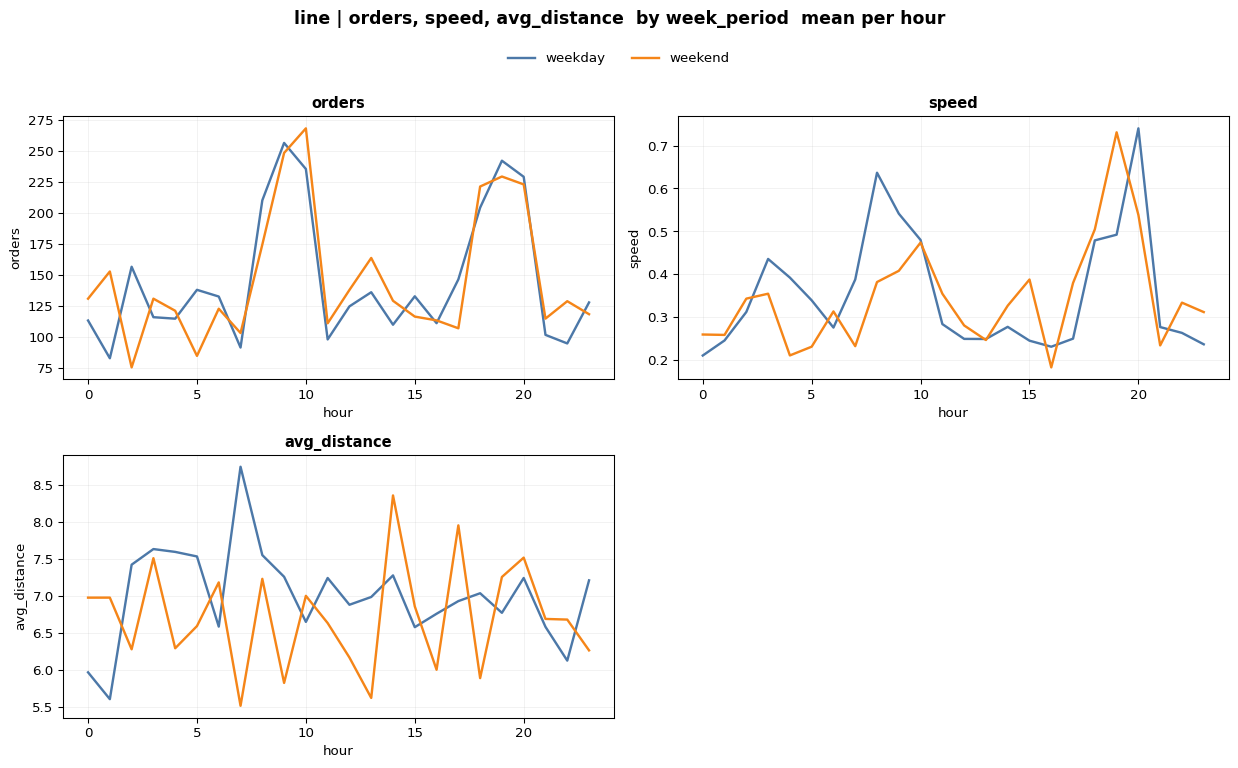

In [18]:
# one panel per column, weekday vs weekend overlaid in each
plotter.plot_columns(long, ['orders', 'speed', 'avg_distance'],
                     x='hour', group='week_period', agg='mean',
                     kind='line', mode='grid')

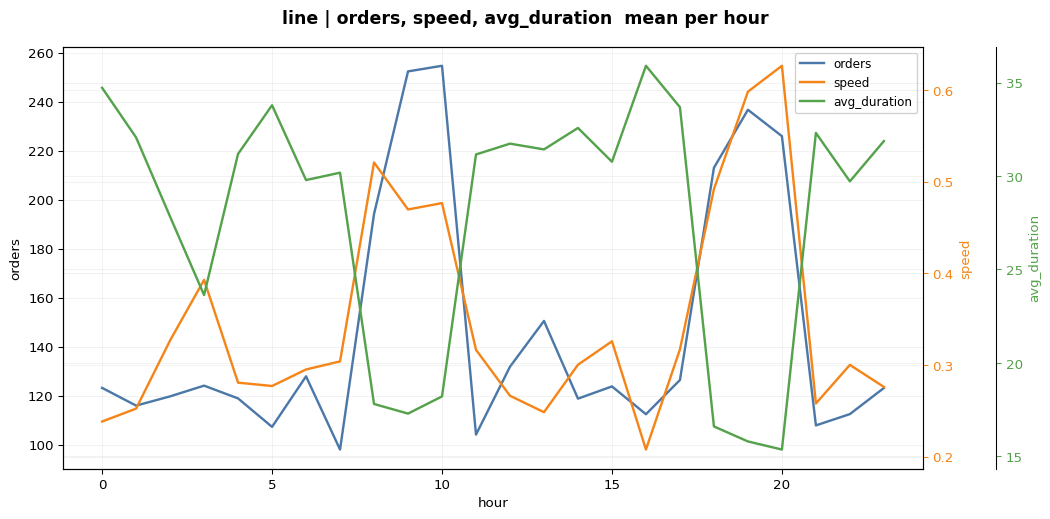

In [19]:
# columns with different scales on one chart, one y-axis each
plotter.plot_multi_axis(long, ['orders', 'speed', 'avg_duration'],
                        x='hour', agg='mean')

### Distributions

`plot_distribution` checks one column (and prints the numbers in the corner);
`compare_distributions` overlays the same variable for every group, one colour
per line.

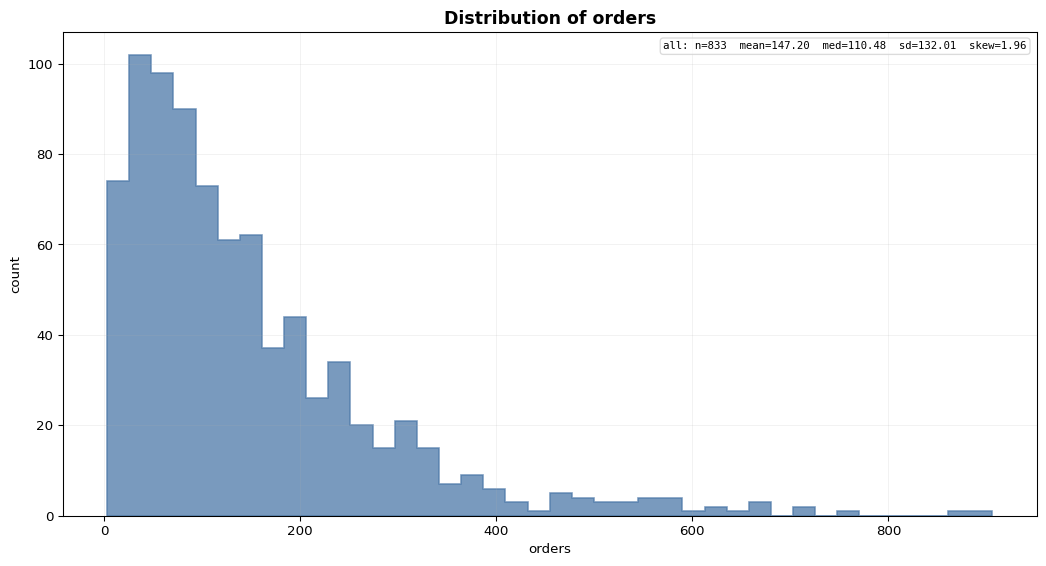

In [20]:
plotter.plot_distribution(long, 'orders', kind='hist', bins=40)

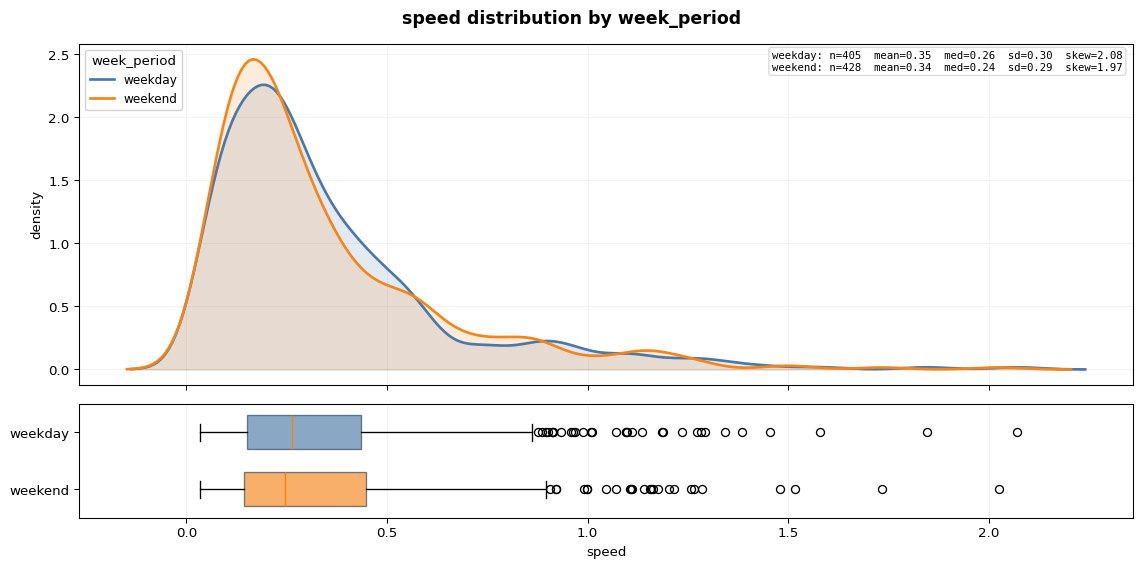

In [21]:
plotter.compare_distributions(long, 'speed', group='week_period',
                              kind='kde', with_box=True)

In [22]:
plotter.describe_distribution(long, 'speed', group='week_period').round(3)

     group  count  missing  n_unique   mean    std    min    max    iqr   skew  kurtosis  outlier_low  \
0  weekday    405        0       405  0.352  0.301  0.033  2.069  0.284  2.079     5.590       -0.274   
1  weekend    428        0       428  0.343  0.295  0.033  2.024  0.304  1.970     4.883       -0.312   

   outlier_high  outlier_share     p1    p25    p50    p75    p99  
0         0.863          0.079  0.042  0.152  0.264  0.436  1.382  
1         0.903          0.058  0.036  0.143  0.245  0.447  1.280  

### Comparing groups

`compare_groups` aggregates per group - the usual test vs control readout.
`normalize_to` expresses every group relative to one baseline.

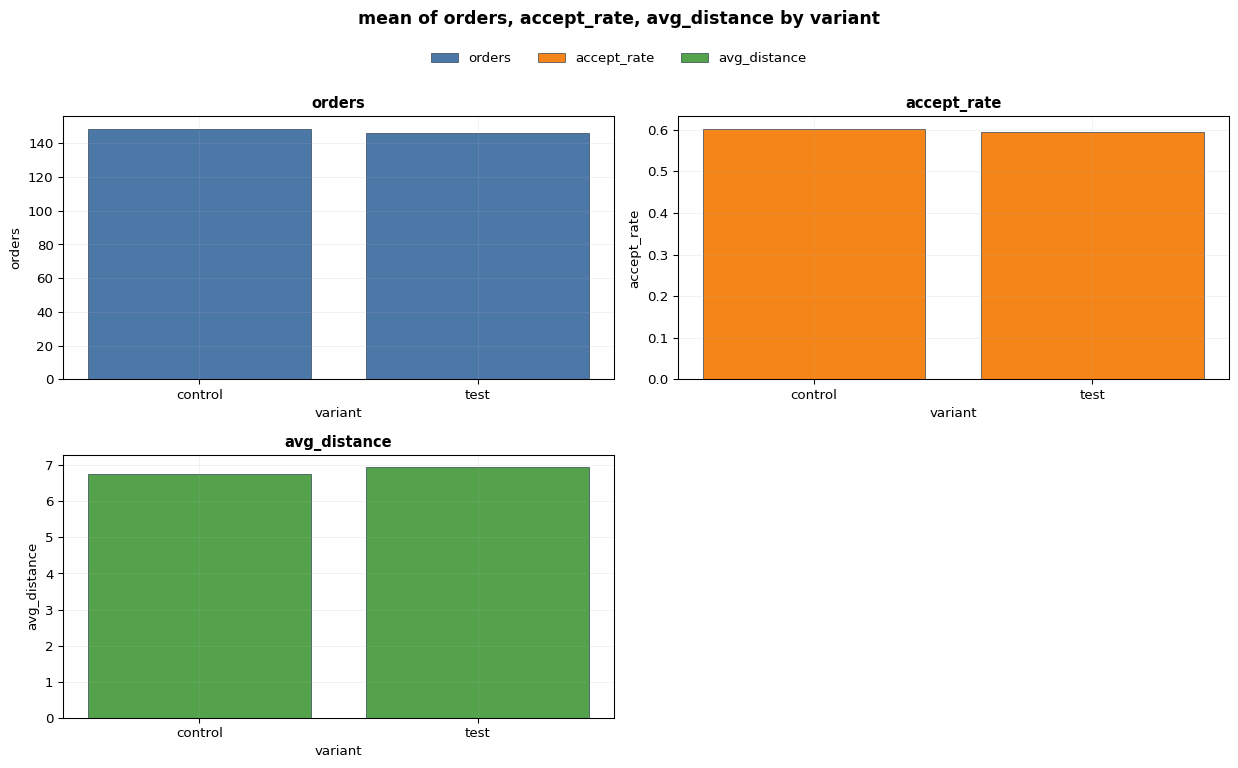

In [23]:
plotter.compare_groups(df, ['orders', 'accept_rate', 'avg_distance'],
                       group='variant', agg='mean')

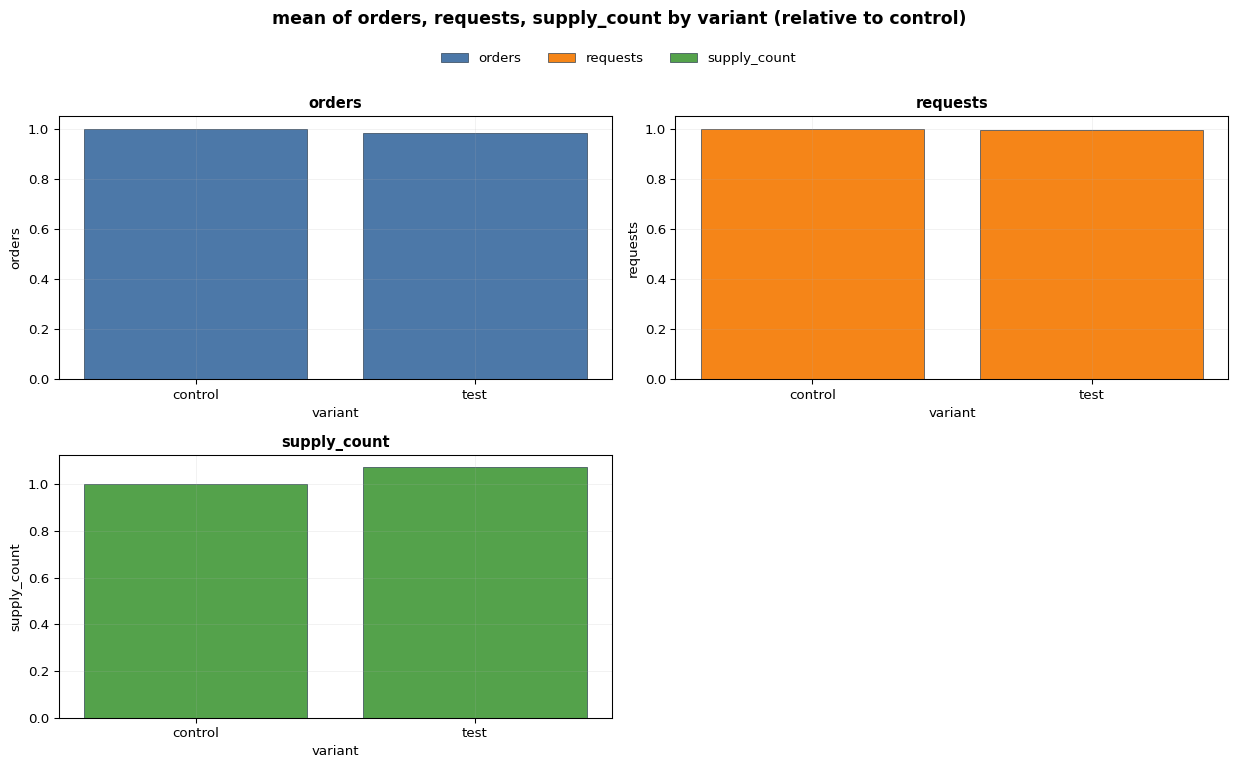

In [24]:
plotter.compare_groups(df, ['orders', 'requests', 'supply_count'],
                       group='variant', agg='mean', normalize_to='control')

In [25]:
plotter.group_stats(df, ['orders', 'avg_distance', 'accept_rate'],
                    group='variant').round(3)

   variant orders                           avg_distance                      accept_rate                \
            count     mean   median     std        count   mean median    std       count   mean median   
0  control    393  148.559  112.535  131.54          393  6.749  6.611  3.030         393  0.602  0.601   
1     test    440  145.981  106.162  132.57          440  6.943  6.878  2.957         440  0.595  0.600   

          
     std  
0  0.165  
1  0.166  